# Task 2: Visualize hidden represenations of a model

In [1]:
import h5py

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import altair as alt

In [2]:
# TODO: your code goes here

embedding_filepath = "../runs/task2/base.h5"  # written by scripts/task2.py

# Reading HDF5 file and extracting embeddings
# Open the HDF5 file in read mode
with h5py.File(embedding_filepath, 'r') as f:
    LANGUAGES = [code.decode('utf-8') for code in f['language_codes'][:]]
    token_embeddings = [np.array(f[f'token_embeddings/{i}'][:]) for i in range(len(f['token_embeddings']))]
    tokens = [[tokens.decode('utf-8') for tokens in f[f'tokens/{i}'][:]] for i in range(len(f['tokens']))]
    sentence_embeddings = [np.array(f[f'sentence_embeddings/{i}'][:]) for i in range(len(f['sentence_embeddings']))]
    sequences = [[sentences.decode('utf-8') for sentences in f[f'sequences/{i}'][:]] for i in range(len(f['sequences']))]
print("Data loaded successfully.")

Data loaded successfully.


In [3]:
print("Shapes of Token Embeddings")
for n, i in enumerate(token_embeddings):
    print(f"Language:{LANGUAGES[n]}:",i.shape)

print("\nTotal Number of Tokens")
for n, i in enumerate(tokens):
    print(f"Language:{LANGUAGES[n]}:",len(i))

print("\nShapes of Sentence embeddings")
for n, i in enumerate(sentence_embeddings):
    print(f"Language:{LANGUAGES[n]}:",i.shape)

print("\nTotal Number of Sequences")
for n, i in enumerate(sequences):
    print(f"Language:{LANGUAGES[n]}:",len(i))

Shapes of Token Embeddings
Language:eng_Latn: (5903, 25, 1024)
Language:spa_Latn: (6683, 25, 1024)
Language:deu_Latn: (6891, 25, 1024)
Language:arb_Arab: (7448, 25, 1024)
Language:tel_Telu: (8290, 25, 1024)
Language:tam_Taml: (8544, 25, 1024)
Language:quy_Latn: (8576, 25, 1024)

Total Number of Tokens
Language:eng_Latn: 5903
Language:spa_Latn: 6683
Language:deu_Latn: 6891
Language:arb_Arab: 7448
Language:tel_Telu: 8290
Language:tam_Taml: 8544
Language:quy_Latn: 8576

Shapes of Sentence embeddings
Language:eng_Latn: (200, 25, 1024)
Language:spa_Latn: (200, 25, 1024)
Language:deu_Latn: (200, 25, 1024)
Language:arb_Arab: (200, 25, 1024)
Language:tel_Telu: (200, 25, 1024)
Language:tam_Taml: (200, 25, 1024)
Language:quy_Latn: (200, 25, 1024)

Total Number of Sequences
Language:eng_Latn: 200
Language:spa_Latn: 200
Language:deu_Latn: 200
Language:arb_Arab: 200
Language:tel_Telu: 200
Language:tam_Taml: 200
Language:quy_Latn: 200


In [4]:
def visualize_embeddings(data, n, method):
    groups = data.groupby('Language')
    # Plot
    fig, ax = plt.subplots()
    ax.margins(0.05) # Optional, just adds 5% padding to the autoscaling
    for name, group in groups:
        ax.scatter(group["Embeddings_0"], group["Embeddings_1"], label=name, alpha=0.5)
    ax.legend()
    if method == 'pca':
        plt.title(f'PCA Visualization for Layer {n}')
        plt.xlabel('Principal Component 1')
        plt.ylabel('Principal Component 2')
    if method == 'tsne':
        plt.title(f'Tsne Visualization for Layer {n}')
        plt.xlabel('Dimension 1')
        plt.ylabel('Dimension 2')
    plt.legend()
    plt.show()

# Token Embeddings

## PCA Visualizations

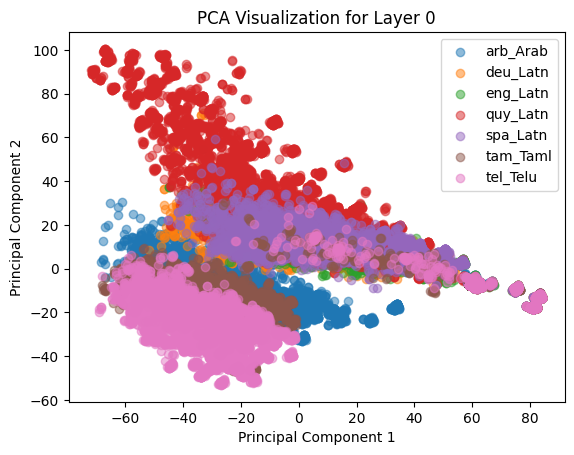

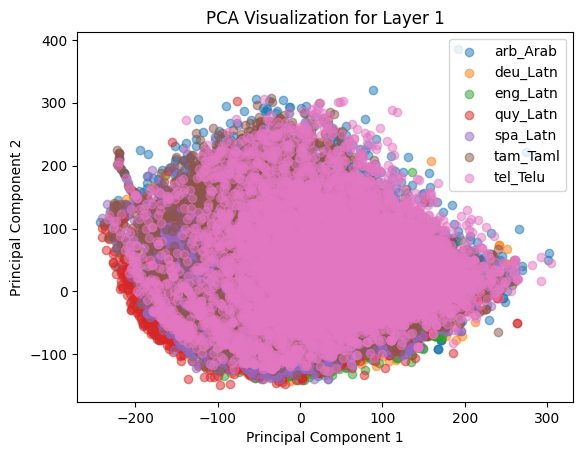

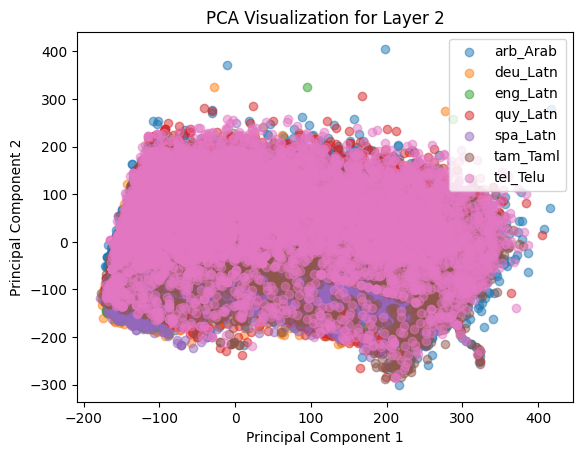

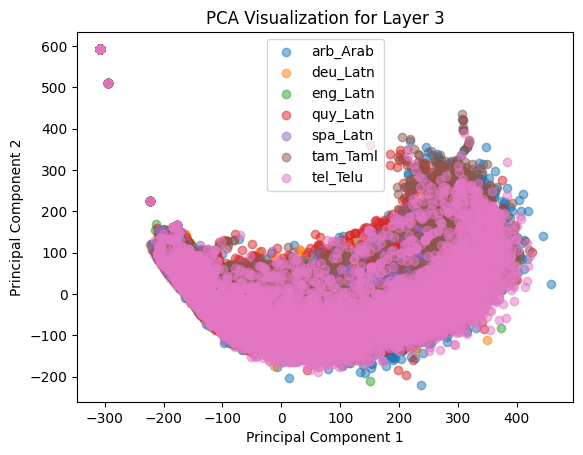

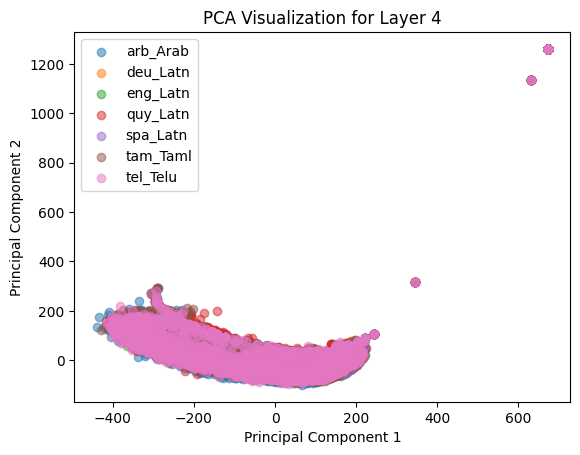

...

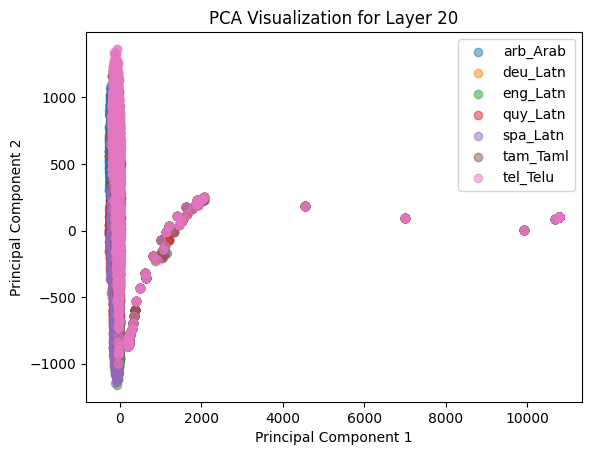

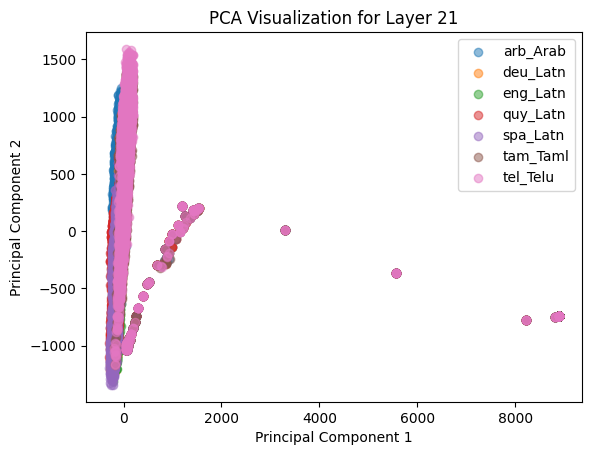

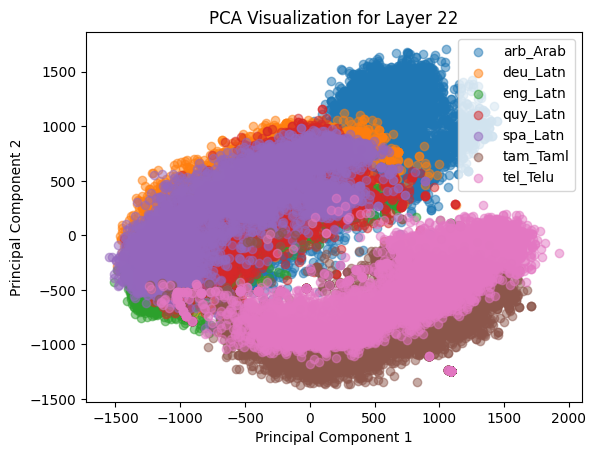

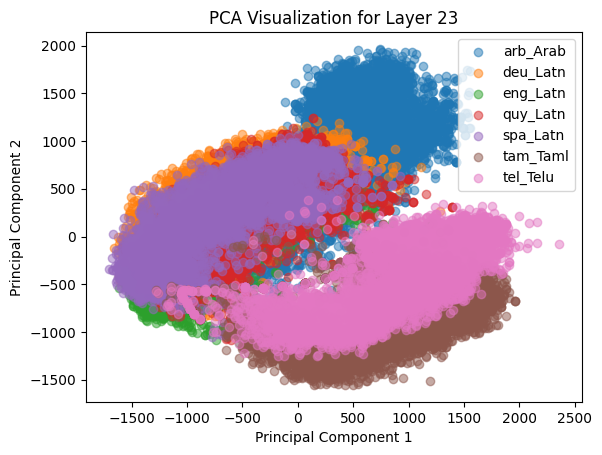

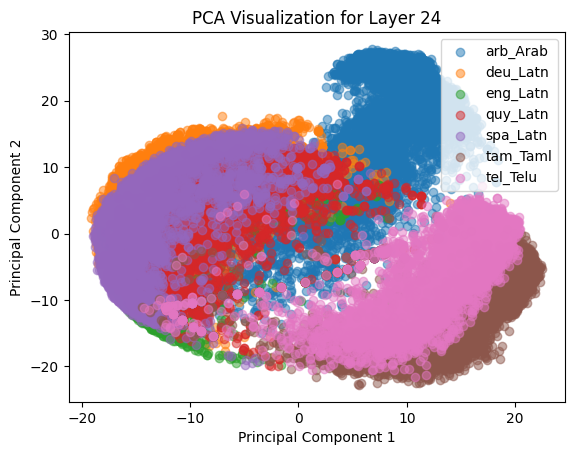

In [ ]:
num_layers = 25           # 24 layers with additional embedding layer in the beggining

for layer_n in range(num_layers):
    token_layer_embedding = np.zeros((0, 1024))
    token_list = []
    lang_list = []
    # GEt flattened embeddings of all languages for each layer
    for i, t_embeddings in enumerate(token_embeddings):
        token_lang_layer_embeddings = t_embeddings[:,layer_n,:]
        token_layer_embedding = np.vstack((token_layer_embedding, token_lang_layer_embeddings))
        token_list.extend(tokens[i])
        lang_list.extend([LANGUAGES[i]] * t_embeddings.shape[0])

    pca = PCA(n_components=2)  # Assuming you want to reduce to 2 dimensions for visualization
    pca_result = pca.fit_transform(token_layer_embedding)

    data = {
        'Embeddings_0' : pca_result[:,0],
        'Embeddings_1' : pca_result[:,1],
        'Tokens': token_list,
        'Language': lang_list
    }
    data_df = pd.DataFrame(data)
    visualize_embeddings(data_df, layer_n, 'pca')

## PCA Visualisation of tokens using Altair chart

Note: The display has issue in loop for all layers so we have displayed for last layer. Also there is limitation of only 5000 samples hence we have selected 500 tokens from each samples to visualze. You can change layer_n to visualize intermediate layers as well

In [11]:
layer_n = 24           # 24 layers with additional embedding layer in the beggining

token_layer_embedding = np.zeros((0, 1024))
token_list = []
lang_list = []
# GEt flattened embeddings of all languages for each layer
for i, t_embeddings in enumerate(token_embeddings):
    token_lang_layer_embeddings = t_embeddings[0:500,layer_n,:]  #selecting only 200 samples
    token_layer_embedding = np.vstack((token_layer_embedding, token_lang_layer_embeddings))
    token_list.extend(tokens[i][0:500])
    lang_list.extend([LANGUAGES[i]] * 500)

pca = PCA(n_components=2)  # Assuming you want to reduce to 2 dimensions for visualization
pca_result = pca.fit_transform(token_layer_embedding)

data = {
    'Embeddings_0' : pca_result[:,0],
    'Embeddings_1' : pca_result[:,1],
    'Tokens': token_list,
    'Language': lang_list
}
data_df = pd.DataFrame(data)

alt.Chart(data_df).mark_circle(size=60).encode(
    x='Embeddings_0:Q',
    y='Embeddings_1:Q',
    color='Language:N',
    tooltip=['Language:N', 'Tokens:N']
).properties(
    title=f'TSNE Visualization for Embeddings of Layer {layer_n}'
).interactive()

alt.Chart(...)

## TSNE Visualizations

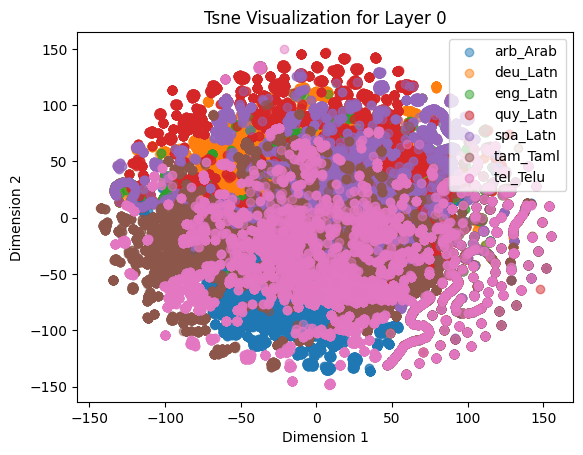

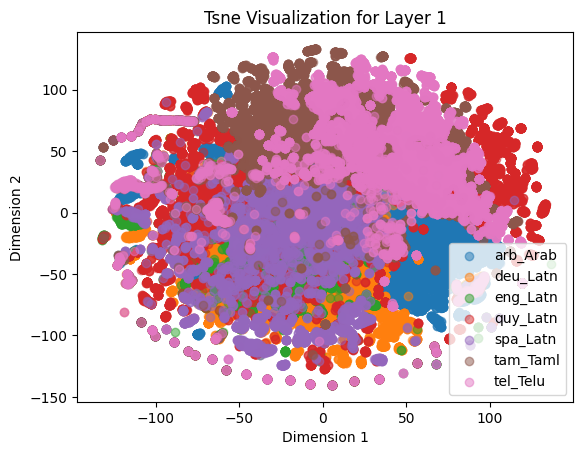

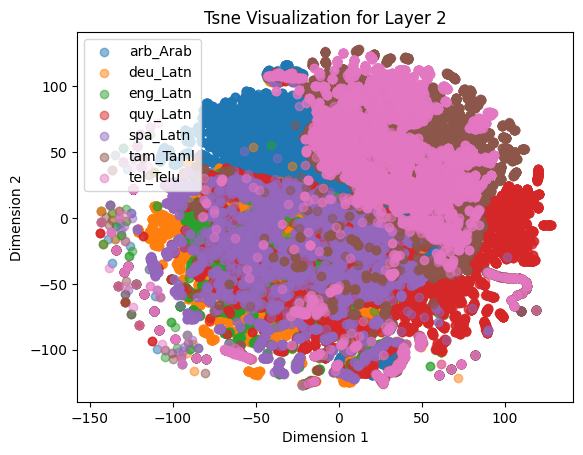

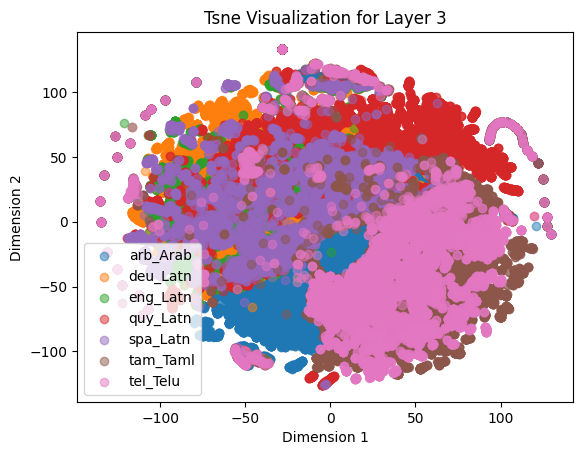

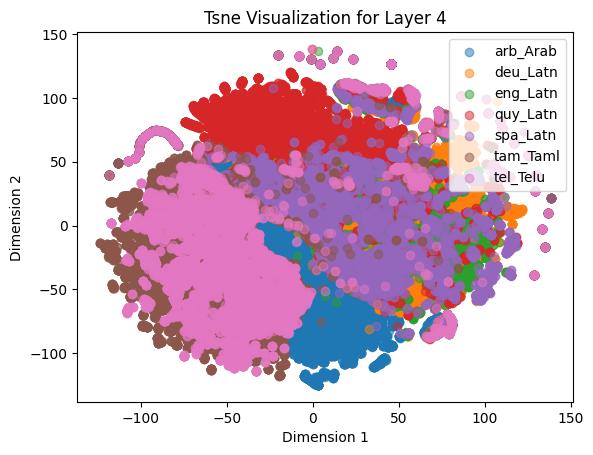

...

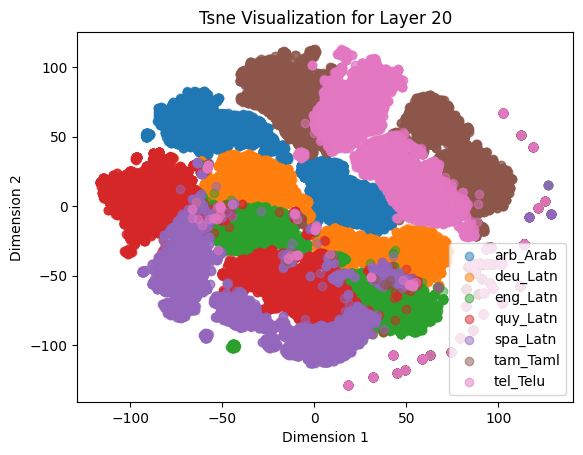

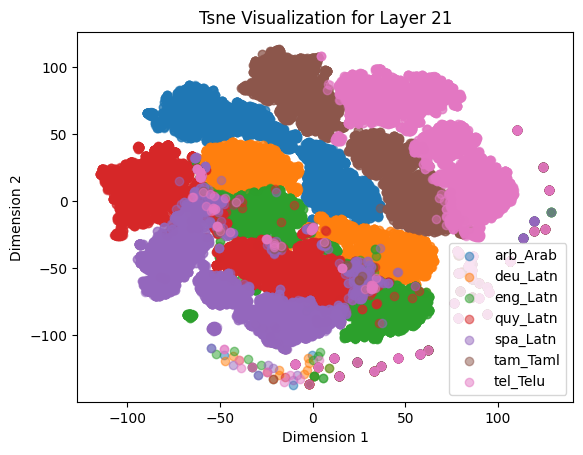

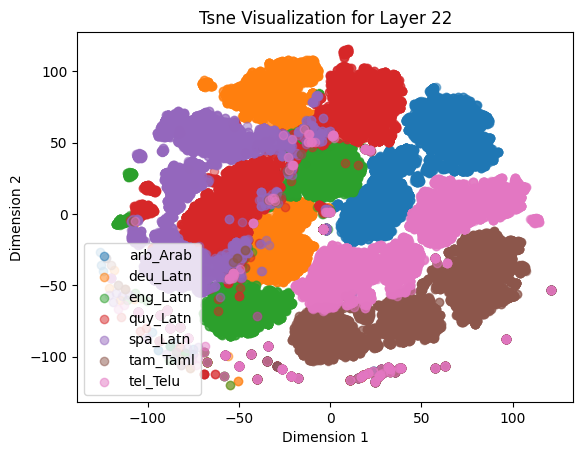

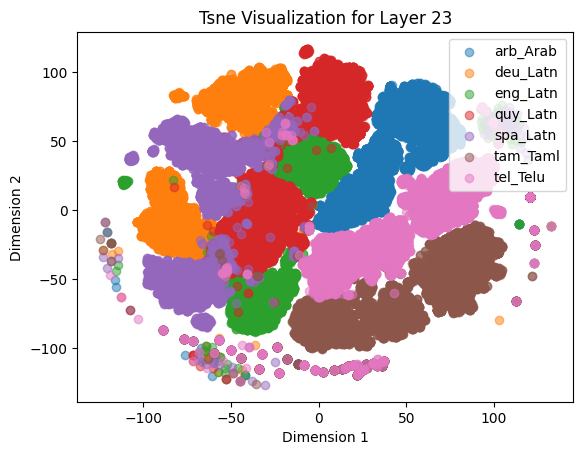

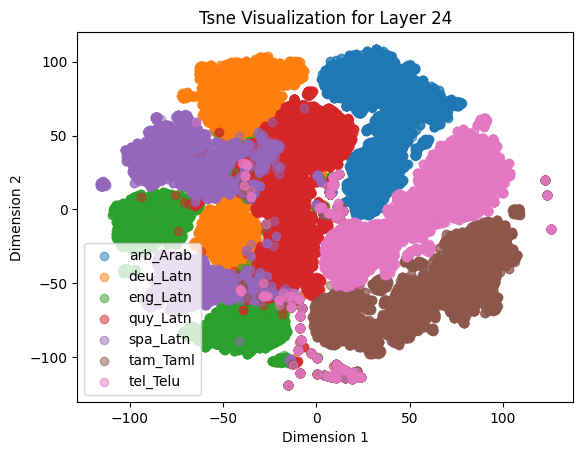

In [6]:
num_layers = 25           # 24 layers with additional embedding layer in the beggining

for layer_n in range(num_layers):
    token_layer_embedding = np.zeros((0, 1024))
    token_list = []
    lang_list = []
    # GEt flattened embeddings of all languages for each layer
    for i, t_embeddings in enumerate(token_embeddings):
        token_lang_layer_embeddings = t_embeddings[:,layer_n,:]
        token_layer_embedding = np.vstack((token_layer_embedding, token_lang_layer_embeddings))
        token_list.extend(tokens[i])
        lang_list.extend([LANGUAGES[i]] * t_embeddings.shape[0])

    tsne = TSNE(n_components=2, random_state=42)
    tsne_result = tsne.fit_transform(token_layer_embedding)

    data = {
        'Embeddings_0' : tsne_result[:,0],
        'Embeddings_1' : tsne_result[:,1],
        'Tokens': token_list,
        'Language': lang_list
    }
    data_df = pd.DataFrame(data)
    visualize_embeddings(data_df, layer_n, 'tsne')

## TSNE Visualisation of tokens using Altair chart

Note: The display has issue in loop for all layers so we have displayed for last layer. Also there is limitation og only 5000 samples hence we have selected 500 tokens from each samples to visualze. You can change layer_n to visualize intermediate layers as well

In [10]:
layer_n = 24           # 24 layers with additional embedding layer in the beggining

token_layer_embedding = np.zeros((0, 1024))
token_list = []
lang_list = []
# GEt flattened embeddings of all languages for each layer
for i, t_embeddings in enumerate(token_embeddings):
    token_lang_layer_embeddings = t_embeddings[0:500,layer_n,:]  #selecting only 200 samples
    token_layer_embedding = np.vstack((token_layer_embedding, token_lang_layer_embeddings))
    token_list.extend(tokens[i][0:500])
    lang_list.extend([LANGUAGES[i]] * 500)

tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(token_layer_embedding)

data = {
    'Embeddings_0' : tsne_result[:,0],
    'Embeddings_1' : tsne_result[:,1],
    'Tokens': token_list,
    'Language': lang_list
}
data_df = pd.DataFrame(data)

alt.Chart(data_df).mark_circle(size=60).encode(
    x='Embeddings_0:Q',
    y='Embeddings_1:Q',
    color='Language:N',
    tooltip=['Language:N', 'Tokens:N']
).properties(
    title=f'TSNE Visualization for Embeddings of Layer {layer_n}'
).interactive()

alt.Chart(...)

# Sentence Embeddings

## PCA Visualizations

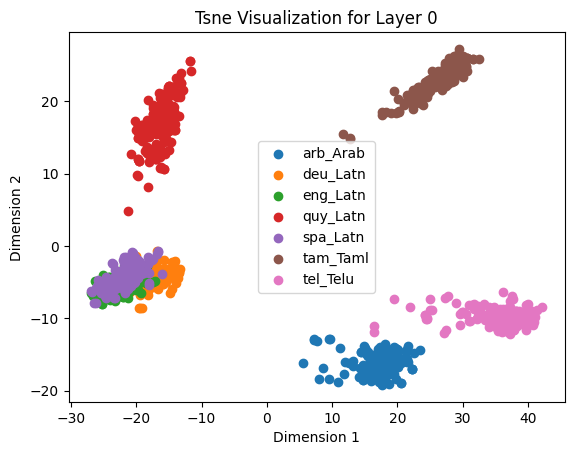

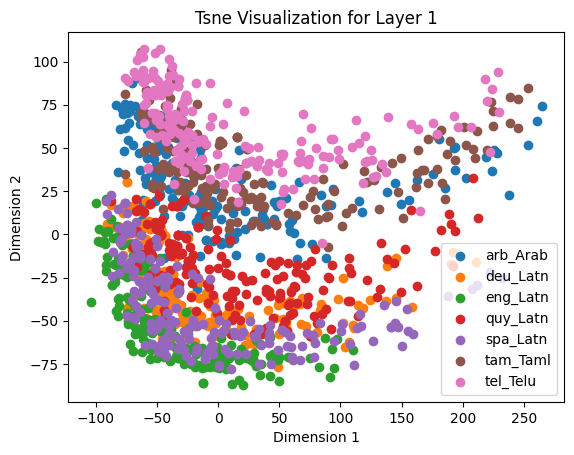

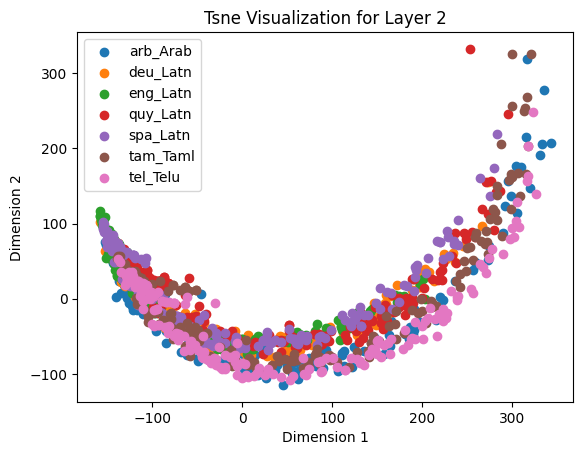

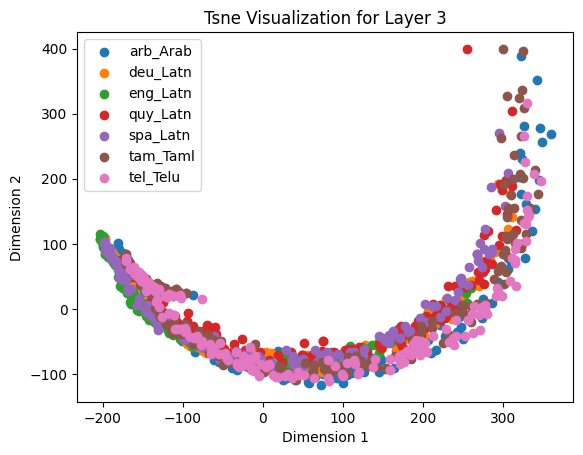

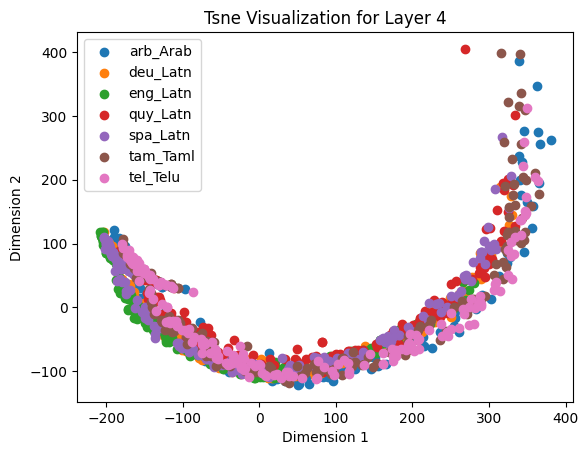

...

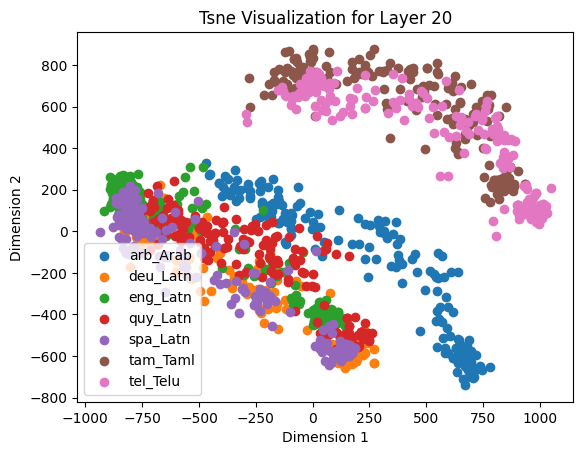

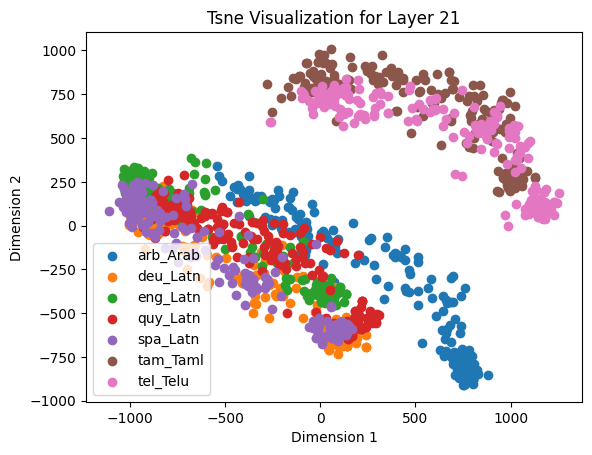

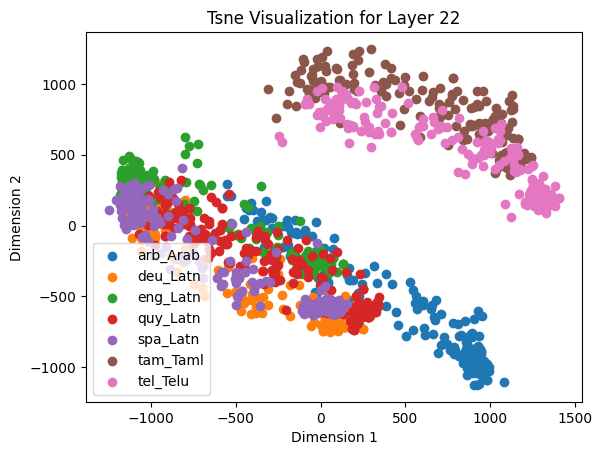

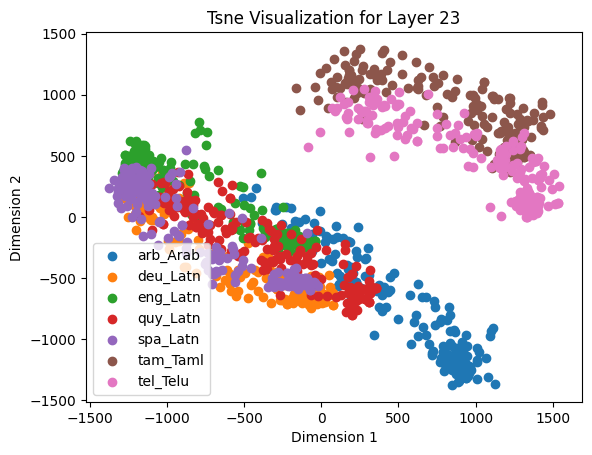

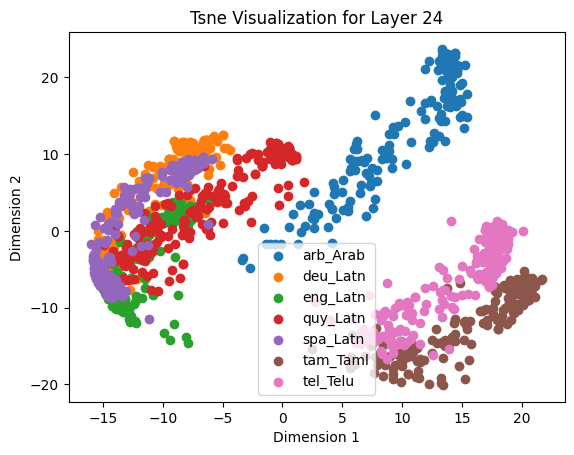

In [ ]:
num_layers = 25           # 24 layers with additional embedding layer in the beggining

for layer_n in range(num_layers):
    sentence_layer_embedding = np.zeros((0, 1024))
    sentence_list = []
    lang_list = []
    # GEt flattened embeddings of all languages for each layer
    for i, s_embeddings in enumerate(sentence_embeddings):
        sentence_lang_layer_embeddings = s_embeddings[:,layer_n,:]
        sentence_layer_embedding = np.vstack((sentence_layer_embedding,sentence_lang_layer_embeddings))
        sentence_list.extend(sequences[i])
        lang_list.extend([LANGUAGES[i]] * s_embeddings.shape[0])

    pca = PCA(n_components=2)  # Assuming you want to reduce to 2 dimensions for visualization
    pca_result = pca.fit_transform(sentence_layer_embedding)

    data = {
        'Embeddings_0' : pca_result[:,0],
        'Embeddings_1' : pca_result[:,1],
        'Sentences': sentence_list,
        'Language': lang_list
    }
    data_df = pd.DataFrame(data)
    visualize_embeddings(data_df, layer_n, 'pca')

## PCA Visualisation of sentences using Altair chart

Note: The display has issue in loop for all layers so we have displayed for first and mid and last layer. However you can change the layer_n to visualize intermediate layer represntations as well

In [ ]:
layer_n = 0

sentence_layer_embedding = np.zeros((0, 1024))
sentence_list = []
lang_list = []
# GEt flattened embeddings of all languages for each layer
for i, s_embeddings in enumerate(sentence_embeddings):
    sentence_lang_layer_embeddings = s_embeddings[:,layer_n,:]
    sentence_layer_embedding = np.vstack((sentence_layer_embedding,sentence_lang_layer_embeddings))
    sentence_list.extend(sequences[i])
    lang_list.extend([LANGUAGES[i]] * s_embeddings.shape[0])

pca = PCA(n_components=2)  # Assuming you want to reduce to 2 dimensions for visualization
pca_result = pca.fit_transform(sentence_layer_embedding)

data = {
    'Embeddings_0' : pca_result[:,0],
    'Embeddings_1' : pca_result[:,1],
    'Sentences': sentence_list,
    'Language': lang_list
}
data_df = pd.DataFrame(data)

alt.Chart(data_df).mark_circle(size=60).encode(
    x='Embeddings_0:Q',
    y='Embeddings_1:Q',
    color='Language:N',
    tooltip=['Language:N', 'Sentences:N']
).properties(
    title=f'PCA Visualization for Embeddings of Layer {layer_n}'
).interactive()

alt.Chart(...)

In [ ]:
layer_n = 24

sentence_layer_embedding = np.zeros((0, 1024))
sentence_list = []
lang_list = []
# GEt flattened embeddings of all languages for each layer
for i, s_embeddings in enumerate(sentence_embeddings):
    sentence_lang_layer_embeddings = s_embeddings[:,layer_n,:]
    sentence_layer_embedding = np.vstack((sentence_layer_embedding,sentence_lang_layer_embeddings))
    sentence_list.extend(sequences[i])
    lang_list.extend([LANGUAGES[i]] * s_embeddings.shape[0])

pca = PCA(n_components=2)  # Assuming you want to reduce to 2 dimensions for visualization
pca_result = pca.fit_transform(sentence_layer_embedding)

data = {
    'Embeddings_0' : pca_result[:,0],
    'Embeddings_1' : pca_result[:,1],
    'Sentences': sentence_list,
    'Language': lang_list
}
data_df = pd.DataFrame(data)

alt.Chart(data_df).mark_circle(size=60).encode(
    x='Embeddings_0:Q',
    y='Embeddings_1:Q',
    color='Language:N',
    tooltip=['Language:N', 'Sentences:N']
).properties(
    title=f'PCA Visualization for Embeddings of Layer {layer_n}'
).interactive()

alt.Chart(...)

## TSNE Visualizations

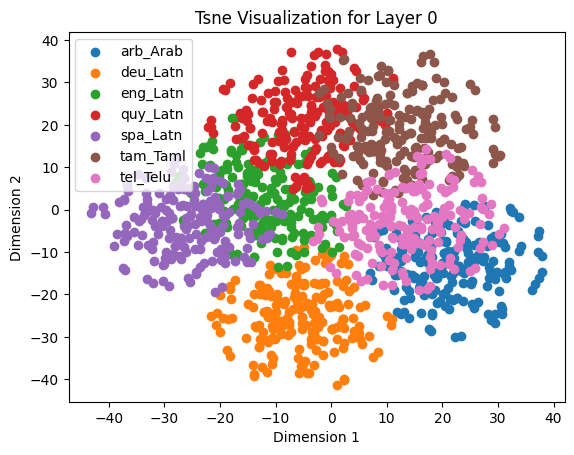

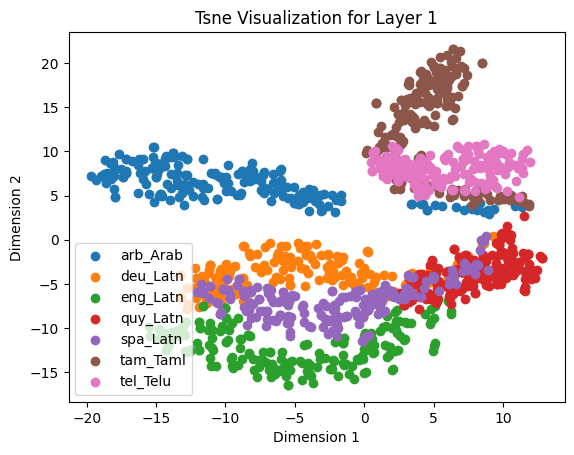

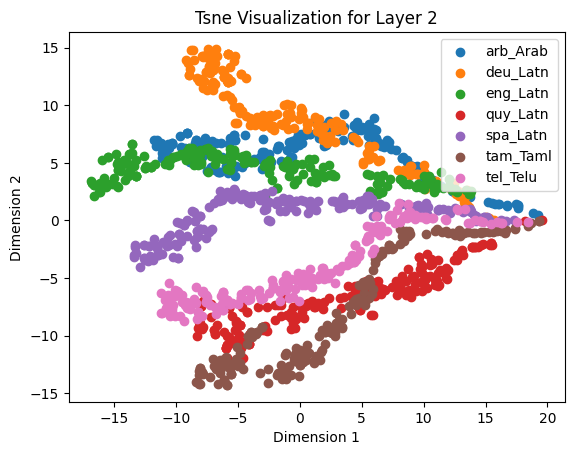

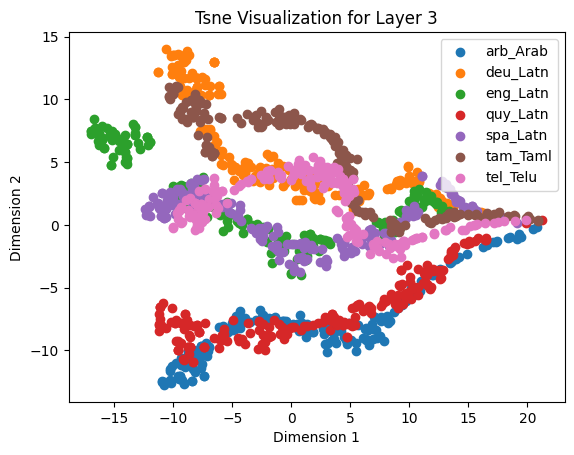

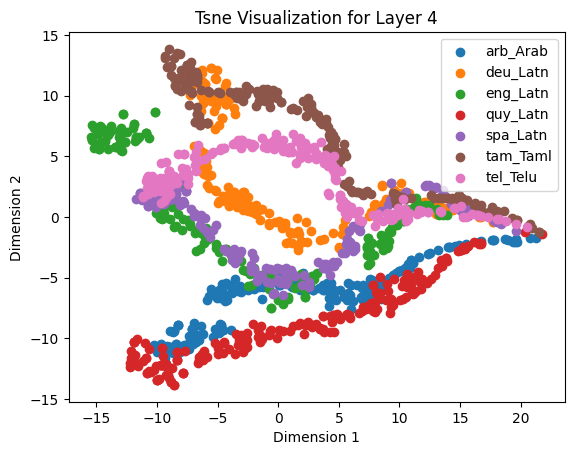

...

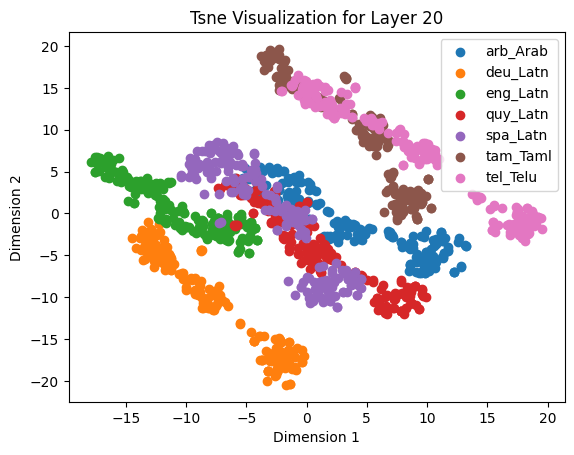

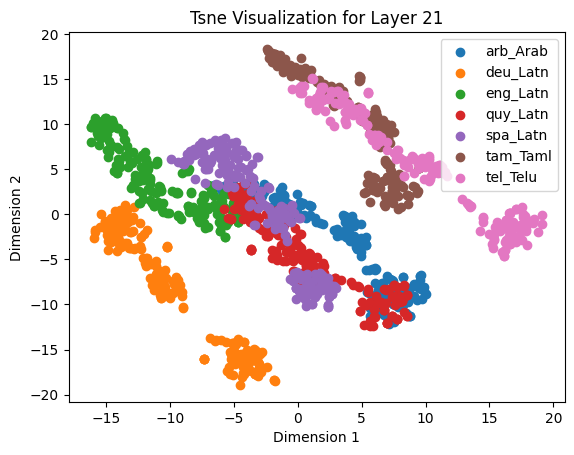

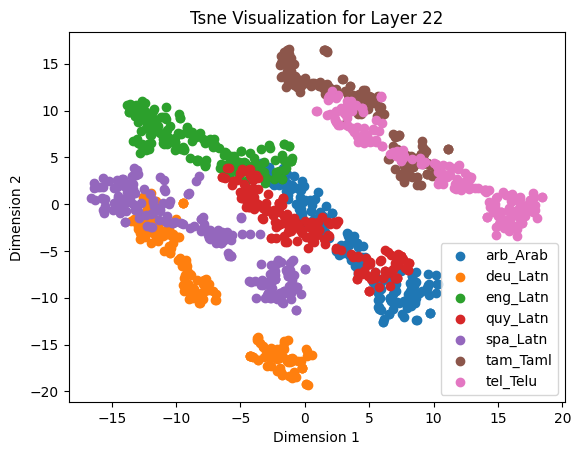

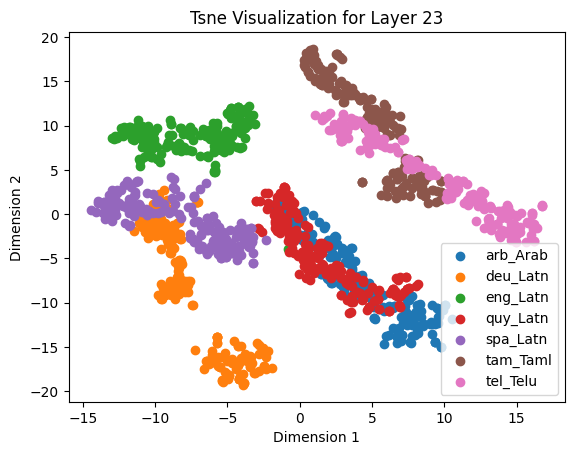

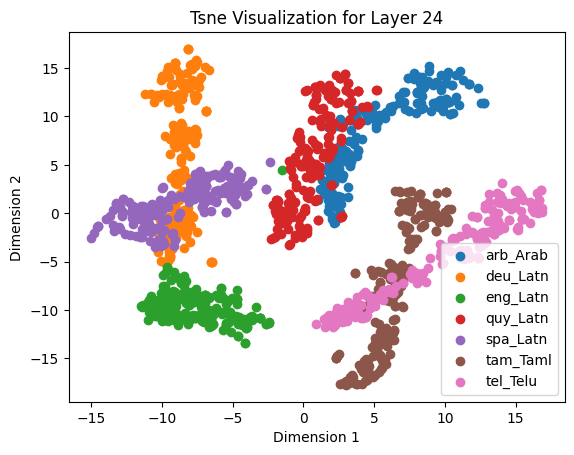

In [ ]:
num_layers = 25           # 24 layers with additional embedding layer in the beggining

for layer_n in range(num_layers):
    sentence_layer_embedding = np.zeros((0, 1024))
    sentence_list = []
    lang_list = []
    # GEt flattened embeddings of all languages for each layer
    for i, s_embeddings in enumerate(sentence_embeddings):
        sentence_lang_layer_embeddings = s_embeddings[:,layer_n,:]
        sentence_layer_embedding = np.vstack((sentence_layer_embedding,sentence_lang_layer_embeddings))
        sentence_list.extend(sequences[i])
        lang_list.extend([LANGUAGES[i]] * s_embeddings.shape[0])

    tsne = TSNE(n_components=3, random_state=42)
    tsne_result = tsne.fit_transform(sentence_layer_embedding)

    data = {
        'Embeddings_0' : tsne_result[:,0],
        'Embeddings_1' : tsne_result[:,1],
        'Sentences': sentence_list,
        'Language': lang_list
    }
    data_df = pd.DataFrame(data)
    visualize_embeddings(data_df, layer_n, 'tsne')


## TSNE Visualisation of sentences using Altair chart

Note: The display has issue in loop for all layers so we have displayed for first and mid and last layer. However you can change the layer_n to visualize intermediate layer represntations as well

In [ ]:
layer_n = 0

sentence_layer_embedding = np.zeros((0, 1024))
sentence_list = []
lang_list = []
# GEt flattened embeddings of all languages for each layer
for i, s_embeddings in enumerate(sentence_embeddings):
    sentence_lang_layer_embeddings = s_embeddings[:,layer_n,:]
    sentence_layer_embedding = np.vstack((sentence_layer_embedding,sentence_lang_layer_embeddings))
    sentence_list.extend(sequences[i])
    lang_list.extend([LANGUAGES[i]] * s_embeddings.shape[0])

tsne = TSNE(n_components=3, random_state=42)
tsne_result = tsne.fit_transform(sentence_layer_embedding)

data = {
    'Embeddings_0' : tsne_result[:,0],
    'Embeddings_1' : tsne_result[:,1],
    'Sentences': sentence_list,
    'Language': lang_list
}
data_df = pd.DataFrame(data)

alt.Chart(data_df).mark_circle(size=60).encode(
    x='Embeddings_0:Q',
    y='Embeddings_1:Q',
    color='Language:N',
    tooltip=['Language:N', 'Sentences:N']
).properties(
    title=f'TSNE Visualization for Embeddings of Layer {layer_n}'
).interactive()

alt.Chart(...)

In [ ]:
layer_n = 24

sentence_layer_embedding = np.zeros((0, 1024))
sentence_list = []
lang_list = []
# GEt flattened embeddings of all languages for each layer
for i, s_embeddings in enumerate(sentence_embeddings):
    sentence_lang_layer_embeddings = s_embeddings[:,layer_n,:]
    sentence_layer_embedding = np.vstack((sentence_layer_embedding,sentence_lang_layer_embeddings))
    sentence_list.extend(sequences[i])
    lang_list.extend([LANGUAGES[i]] * s_embeddings.shape[0])

tsne = TSNE(n_components=3, random_state=42)
tsne_result = tsne.fit_transform(sentence_layer_embedding)

data = {
    'Embeddings_0' : tsne_result[:,0],
    'Embeddings_1' : tsne_result[:,1],
    'Sentences': sentence_list,
    'Language': lang_list
}
data_df = pd.DataFrame(data)

alt.Chart(data_df).mark_circle(size=60).encode(
    x='Embeddings_0:Q',
    y='Embeddings_1:Q',
    color='Language:N',
    tooltip=['Language:N', 'Sentences:N']
).properties(
    title=f'TSNE Visualization for Embeddings of Layer {layer_n}'
).interactive()

alt.Chart(...)